# Range Detection Engine – Statistical Validation v1 
## Mean Reversion Analysis
The goal of this stage is structural validation — not parameter optimization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
rs = pd.read_csv("eurusd_rs_v1.csv", parse_dates=["date"], index_col="date")
mr = pd.read_csv("eurusd_mr_v1.csv", parse_dates=["date"], index_col="date")

In [3]:
rs = rs[["range_score", "regime"]]
mr = mr[["price", "mr", "dist", "dist_next", "md", "md3", "3m"]]

In [4]:
df = mr.join(rs, how="inner")
df.head()

,price,mr,dist,dist_next,md,md3,3m,range_score,regime
date,,,,,,,,,
2023-01-02 07:00:00,1.06967,0,0.00127,-0.00159,1.07075,1.073523,2023Q1,35.410558,-1
2023-01-02 08:00:00,1.06935,0,0.00159,-0.00303,1.07075,1.073523,2023Q1,20.754482,-1
2023-01-02 09:00:00,1.06791,0,0.00303,-0.00306,1.07075,1.073523,2023Q1,19.764735,-1
2023-01-02 10:00:00,1.06788,0,0.00306,-0.00310,1.07075,1.073523,2023Q1,23.124900,-1
2023-01-02 11:00:00,1.06784,1,0.00310,0.00258,1.07075,1.073523,2023Q1,26.461965,-1


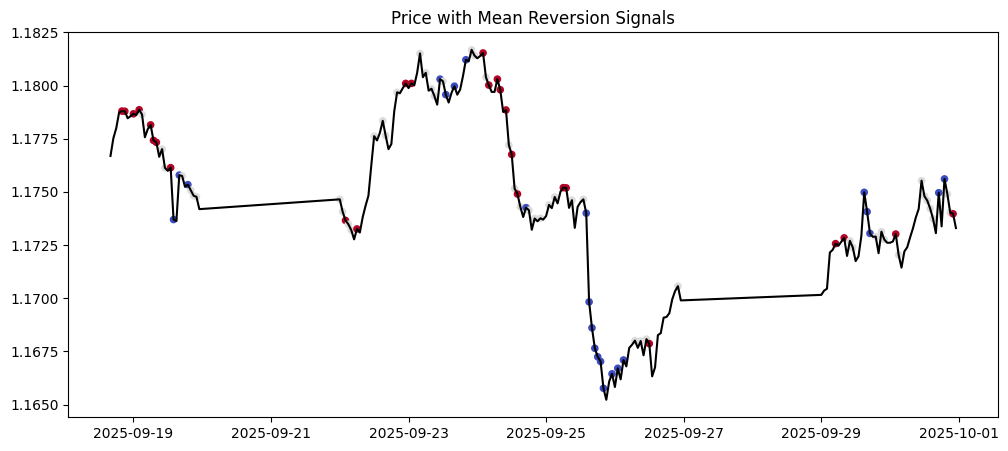

In [5]:
n = 200
d = df.tail(n)

plt.figure(figsize=(12,5))

plt.plot(d.index, d["price"], color="black")

plt.scatter(d[d["mr"]==1].index, d[d["mr"]==1]["price"], c=d[d["mr"]==1]["regime"], cmap="coolwarm", s=20)
plt.title("Price with Mean Reversion Signals")

plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/MRSignalsByRegime.png")
plt.show()

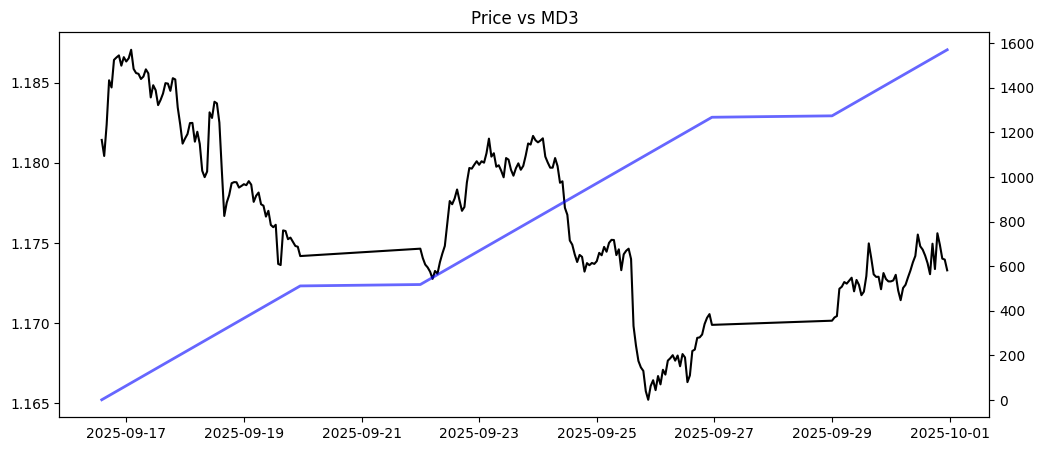

In [6]:
n = 250
d = df.tail(n).copy()

x = np.arange(len(d))

y1 = d["md3"].iloc[0]
y2 = 1571

x1 = 0
x2 = len(d) - 1

m = (y2 - y1) / (x2 - x1)
b = y1 - m * x1

d["md3_line"] = m * x + b

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(d.index, d["price"], color="black")
ax2 = ax1.twinx()

ax2.plot(d.index, d["md3_line"], color="blue", linewidth=2, alpha=0.6)

plt.title("Price vs MD3")
plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/ValidationPrice_MD3.png")

plt.show()

In [7]:
df.to_csv(r"C:\Users\LENOVO\AlgoTrading_Research\statistical-range-detection\data\processed\eurusd_MR_analysis.csv")